In [23]:
# os
import os

# Computations
import numpy as np
import scipy as sp
import sympy as smp

# Science
import CoolProp.CoolProp as CP
import gsw

# System
import yaml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Data handling
import pandas as pd



In [25]:
# project name
PROJECT_NAME = "ProjectAquarium"

# extract full project path
path_of_paths_file = os.path.abspath(__name__)
corresponding_basename = os.path.basename(__name__)
initial_directory_path = path_of_paths_file[:-len(corresponding_basename)]
os.chdir(initial_directory_path)
initial_directory_name = os.getcwd()[-len(PROJECT_NAME):]

if initial_directory_name == PROJECT_NAME:
    print(f"initialized focus in project folder {PROJECT_NAME}")
else:
    raise Exception(
        f"initiated focus in folder {initial_directory_name}, should have been {PROJECT_NAME}")

PROJECT_PATH = os.getcwd()
project_path = ""

Exception: initiated focus in folder otes/wave maker, should have been ProjectAquarium

In [2]:
sns.set_theme()
plt.rcParams['text.usetex'] = True

In [3]:
# aliases
norm = sp.linalg.norm
pi = np.pi

In [4]:
# constants (SI)
g0 = sp.constants.g     # At sea level
p0 = sp.constants.atm   # At sea level
T_room = 290            # Israeli winter temperature in Kelvin

density = CP.PropsSI('D', 'T', T_room, 'P', p0, 'Water')
viscosity = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water')  # Pa.s
kinematic_viscosity = viscosity / density
surface_tension = 0.074  # N/m, estimate for seawater, +-0.001

# aliases
rho = density
mu = viscosity
nu = kinematic_viscosity
tau = surface_tension


In [5]:
print("density = ", rho, "\nsurface_tension = ", tau)

density =  998.8039147159017 
surface_tension =  0.074


## complex dispersion == dispersion + damping

In [6]:
# Dispersion relation, capillary-gravity, short waves limit.
def dr_cg_sw(k):
    k = norm(k, axis=-1)
    return np.sqrt((g0 * k + tau/rho * k**3))

In [7]:
N = int(1e3)
k_max = 2*np.pi*int(1e3)
ks = np.linspace(k_max/N, k_max, num=N).reshape((N,1))

In [8]:
def f_omega(omega, k):
    k_abs = np.abs(k)
    lhs = (2 - 1j*omega/(nu*k_abs**2))**2 + (k_abs*(g0 + surface_tension/density * k_abs**2)) / (nu**2 * k_abs**4)
    rhs = 4 * np.sqrt(1 - 1j*omega/(nu*k_abs**2))
    return lhs - rhs

# --- Solver for one k ---
def solve_for_k(k):
    # initial guess: inviscid dispersion relation
    omega0 = np.sqrt(g0*k + surface_tension/density*k**3)
    # solve numerically
    sol = sp.optimize.newton(func=lambda w: f_omega(w, k), x0=omega0, maxiter=1000, tol=1e-10)
    return sol

omegas = np.array([solve_for_k(k) for k in ks])[:,0]


In [9]:
frequencies = np.real(omegas)/(2*pi)
decay_rates = np.imag(omegas)

### dispersion (inverted): wavenumber vs. frequency

Text(0, 0.5, '$\\frac{|k|}{2\\pi} [cm^{-1}]$')

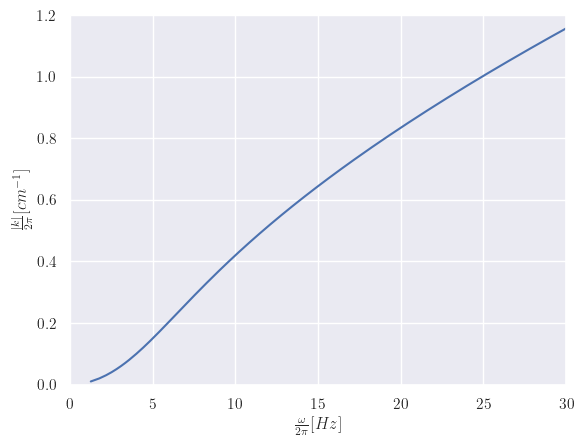

In [10]:
plt.plot(frequencies, norm(ks, axis=-1)/(2*np.pi)/100)
plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 120/100)
plt.ylabel(r"$\frac{|k|}{2\pi} [cm^{-1}]$")

### group velocity vs. frequency

Text(6.268374984405985, 17.834527740899762, '(6.27, 17.83)')

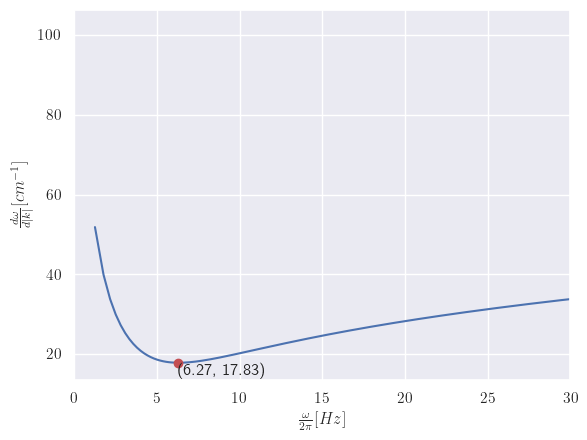

In [11]:
dwdks = np.diff(frequencies)/np.diff(norm(ks, axis=-1)/(2*np.pi)/100)
plt.plot(frequencies[:-1], dwdks)
plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0,0.1)
plt.ylabel(r"$\frac{d\omega}{d|k|} [cm^{-1}]$")
i_min = np.argmin(dwdks)
w_min = frequencies[i_min]
v_min = dwdks[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='top')


### Bond number vs. frequency

0.9966747775019392


Text(0, 0.5, 'tension/gravity contribution ratio')

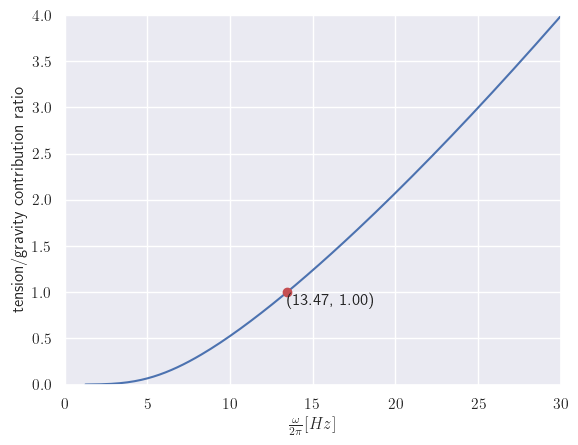

In [12]:
Bo = rho*g0 / (tau * ks**2)
plt.plot(frequencies, 1/Bo)
i_equal = np.argmin((Bo-1)**2)
w_equal = frequencies[i_equal]
Bo_equal = Bo[i_equal][0]
print(Bo_equal)
plt.plot([w_equal], [Bo_equal], 'ro')
plt.text(w_equal, Bo_equal, f"({w_equal:.2f}, {Bo_equal:.2f})", fontsize=12, ha='left', va='top')
plt.xlim(0, 30)
plt.ylim(0, 4)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel("tension/gravity contribution ratio")

### phase velocity vs frequency

Text(0, 0.5, '$v_{phase}[ms^{-1}]$')

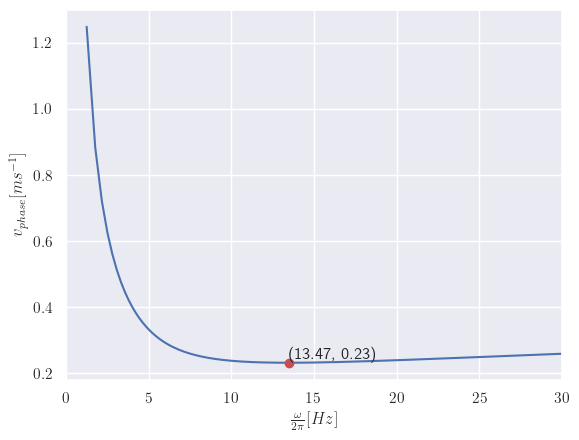

In [13]:
N = int(1e3)
k_max = 2*np.pi*int(1e3)
vs = np.real(omegas)/norm(ks, axis=-1)
plt.plot(frequencies, vs)

i_min = np.argmin(vs)
w_min = frequencies[i_min]
v_min = vs[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='bottom')

plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 120/100)
plt.ylabel(r"$v_{phase}[ms^{-1}]$")

### decay rate vs. frequency

Text(0, 0.5, '$\\alpha \\left[s^{-1}\\right]$')

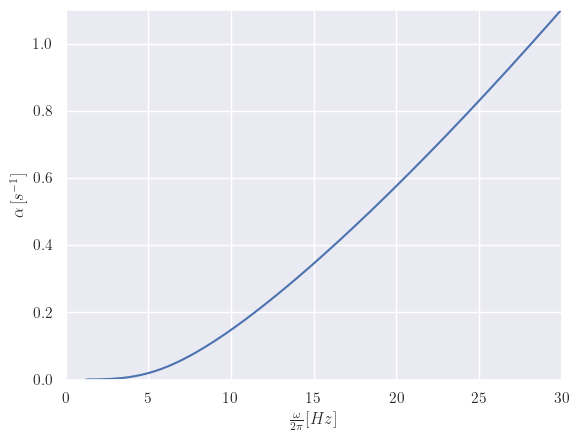

In [14]:
plt.plot(np.real(omegas)/(2*np.pi), -np.imag(omegas))
plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 1.1)
plt.ylabel(r"$\alpha \left[s^{-1}\right]$")

## Wave making theory

In [22]:
# Constants

## Indices
XIND = 0
YIND = 1

## Physical parameters
with open("design/aquarium/aquarium.yaml", "r") as f:
    aquarium_params = yaml.safe_load(f)

H = aquarium_params["z_inner"]

FileNotFoundError: [Errno 2] No such file or directory: 'design/aquarium/aquarium.yaml'

In [ ]:
def evanescent_dispersion_eq(k)
    g0*k*np.tan(k*H) - (tau/rho)*k**3

In [ ]:
# def generate_waveform(B, phi, omega, gamma, k, h):
#     def zeta(t, x, y):
#         return (
#         1j * np.sum(
#             B
#             * (np.abs(k) / omega)
#             * np.sinh(h * np.abs(k))
#             * np.cos(k[XIND] * x)
#             * np.cos(k[YIND] * y)
#             * np.exp(-gamma * t)
#             * np.cos(omega * t + phi)
#             )
#         )
#     return zeta

In [ ]:
def alpha(z, d, alpha_val):
    """
    Piecewise alpha function.
    """
    if -d < z < 0:
        return alpha_val
    elif -H < z <= -d:
        return 0
    else:
        raise ValueError("z out of range")

def B_m0(k_p, h, z_m, alpha_val, d):
    a = alpha(z_m, d, alpha_val)
    return k_p * (
        1j * np.cosh(k_p * h * (1 + z_m/h)) 
        - np.tan(a) * np.sinh(k_p * h * (1 + z_m/h))
    ) * np.exp(1j * k_p * h * np.tan(a) * (d/h + z_m/h))

def B_mn(k_s_n, h, z_m, alpha_val, d):
    a = alpha(z_m, d, alpha_val)
    return -k_s_n * (
        np.cos(k_s_n * h * (1 + z_m/h)) 
        - np.tan(a) * np.sin(k_s_n * h * (1 + z_m/h))
    ) * np.exp(-k_s_n * h * np.tan(a) * (d/h + z_m/h))

def D_m(S, omega_p, z_m, d, alpha_val):
    a = alpha(z_m, d, alpha_val)
    return S * omega_p * np.tan(a)

In [ ]:


# Propagating wave number k_p
def get_kp(f):
    def dispersion_kp(k):
        return g0*k*np.tanh(k*H) + (tau/rho)*k**3 - (2*pi*f)**2

    k_p_guess = (2*pi*f)**2 / g0
    k_p = sp.optimize.fsolve(dispersion_kp, k_p_guess)[0]
    
    return k_p

# Evanescent modes k_{s,n}
def get_ks(f, N):
    def k_s_n(n):
        # Approx first guess
        k_guess = n*np.pi/H
        def dispersion_ksn(k):
            return -g0*k*np.tan(k*H) + (tau/rho)*k**3 - (2*pi*f)**2
        
        return sp.optimize.fsolve(dispersion_ksn, k_guess)[0]

    # Example: first 3 evanescent modes
    k_s = [k_s_n(n) for n in range(1, 4)]

print("k_p =", k_p)
print("k_s_n =", k_s)

In [ ]:
# Example usage
B0 = B_m0(k_p, H, z_m, alpha_val, d)
Bn = B_mn(k_s_n, H, z_m, alpha_val, d)
D = D_m(S, omega_p, z_m, d, alpha_val)

# Amplitudes
A0 = A_p = 1.0
An = A_s_n = 0.5